# Diabetes Prediction using XGBoost: End-to-End Machine Learning Pipeline

## Project Goal
Build a complete ML pipeline for predicting diabetes diagnosis using demographic, lifestyle, medical, and laboratory data.

### Improvements in this version
- ✅ **Leakage removed**: `diabetes_risk_score` and `diabetes_stage` dropped (they encode the label)
- ✅ **Feature Engineering**: Clinical ratios, binned thresholds, lifestyle score, interaction flags
- ✅ **Cross-Validation**: Stratified 5-Fold CV for reliable evaluation across all data
- ✅ **Early Stopping**: XGBoost stops adding trees when validation loss plateaus

### Pipeline Steps
1. Business & Data Understanding
2. Load Dataset
3. Missing Value Analysis
4. EDA (Class Distribution, Distributions, Correlation)
5. Remove Leaky Features
6. Feature Engineering
7. Preprocessing Pipeline
8. Cross-Validation Evaluation
9. Final Model Training with Early Stopping
10. Evaluation (Accuracy, Classification Report, ROC AUC)
11. Feature Importance
12. Save Final Model

## 1. Imports

In [43]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
import joblib

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Dataset

In [44]:
Data_Path = os.path.join(os.getcwd(), 'Data/diabetes', 'diabetes.csv')
df = pd.read_csv(Data_Path)

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


## 3. Missing Value Analysis

In [47]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(12, 5))
    missing.sort_values().plot(kind='bar')
    plt.title('Missing Values Per Column')
    plt.xlabel('Features')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in dataset.')

No missing values found in dataset.


## 4. Exploratory Data Analysis

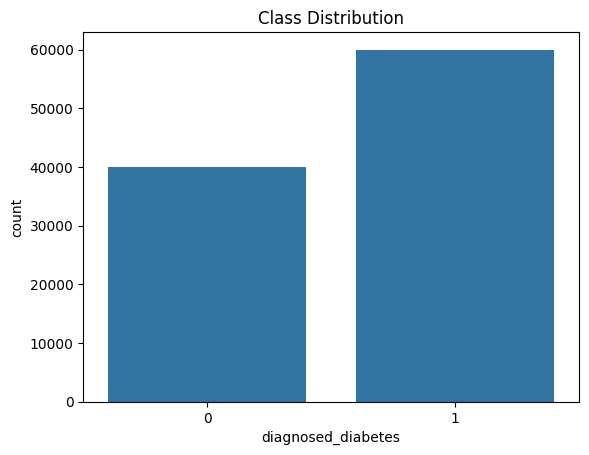

diagnosed_diabetes
1    59.998
0    40.002
Name: proportion, dtype: float64


In [48]:
# --- Class Distribution ---
sns.countplot(data=df, x='diagnosed_diabetes')
plt.title('Class Distribution')
plt.show()

print(df['diagnosed_diabetes'].value_counts(normalize=True) * 100)

In [49]:
# --- Separate feature types (excluding leaky columns from EDA too) ---
LEAKY_COLS = ['diabetes_risk_score', 'diabetes_stage']

df_eda = df.drop(columns=LEAKY_COLS, errors='ignore')

categorical = df_eda.select_dtypes(include='object').columns.tolist()
numerical   = df_eda.select_dtypes(exclude='object').columns.tolist()
numerical.remove('diagnosed_diabetes')

print('Categorical:', categorical)
print('Numerical  :', numerical)

Categorical: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
Numerical  : ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']


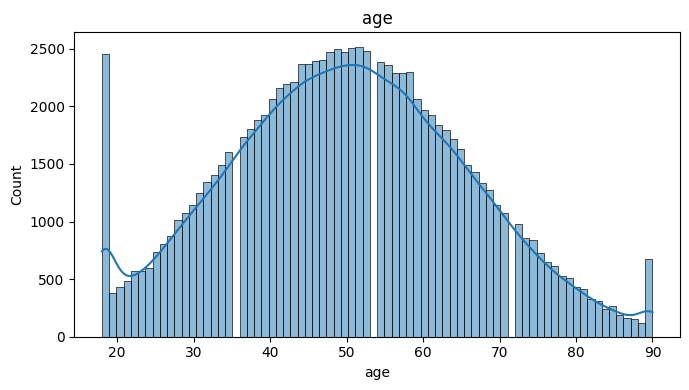

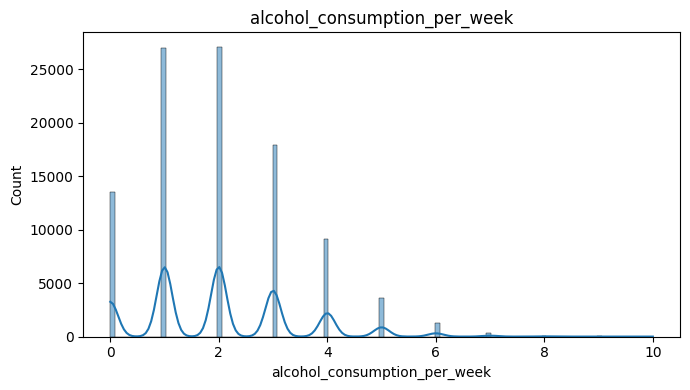

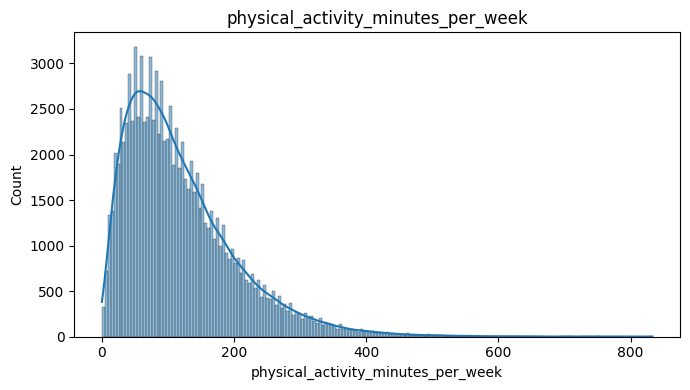

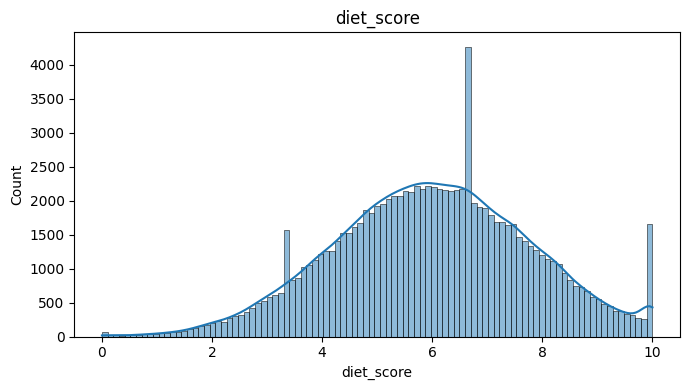

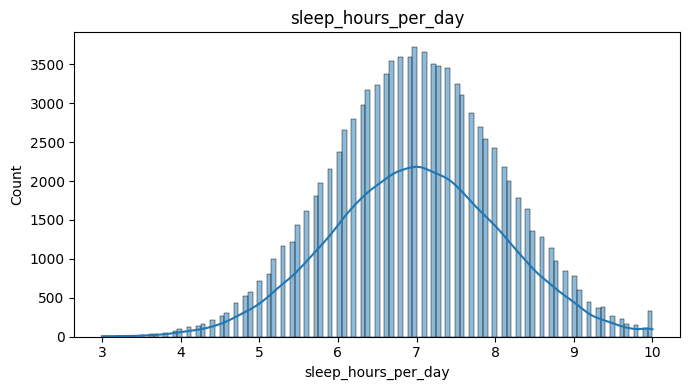

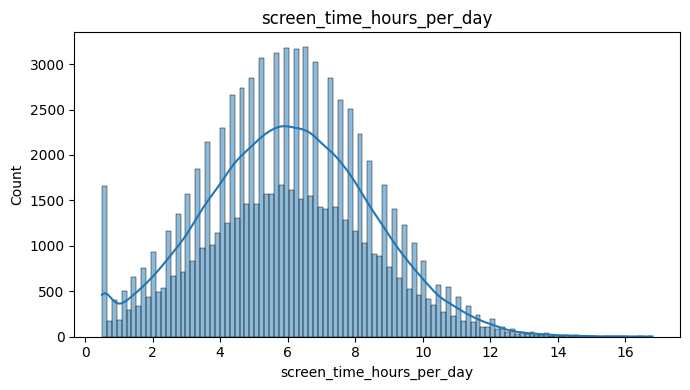

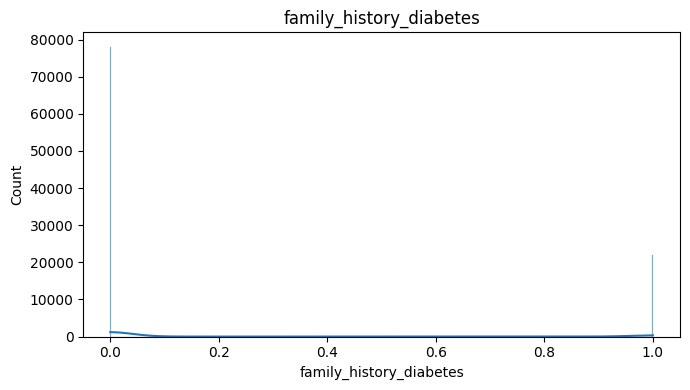

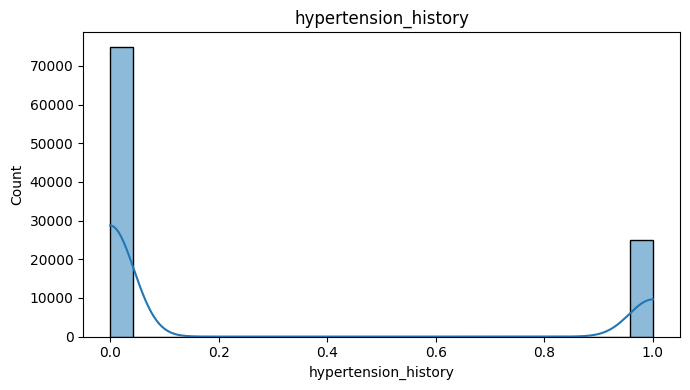

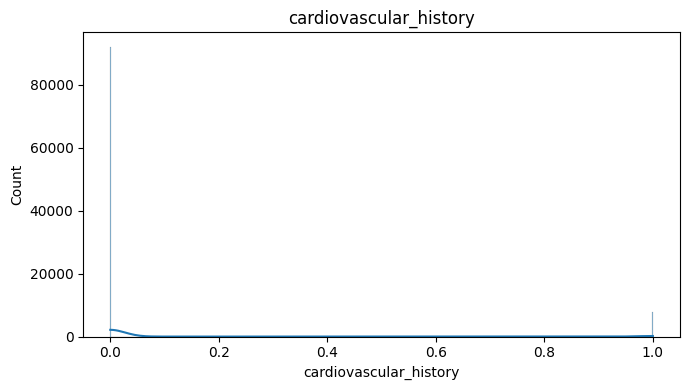

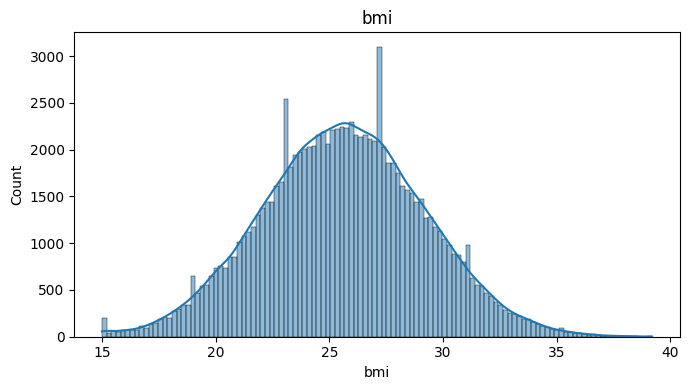

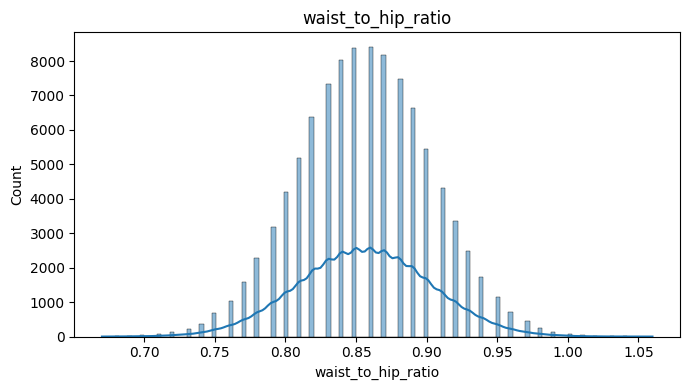

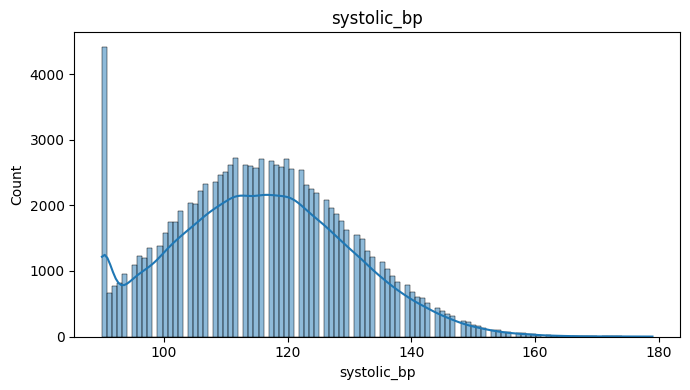

In [50]:
# --- Numerical Feature Distributions ---
for col in numerical[:12]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_eda[col], kde=True)
    plt.title(col)
    plt.tight_layout()
    plt.show()

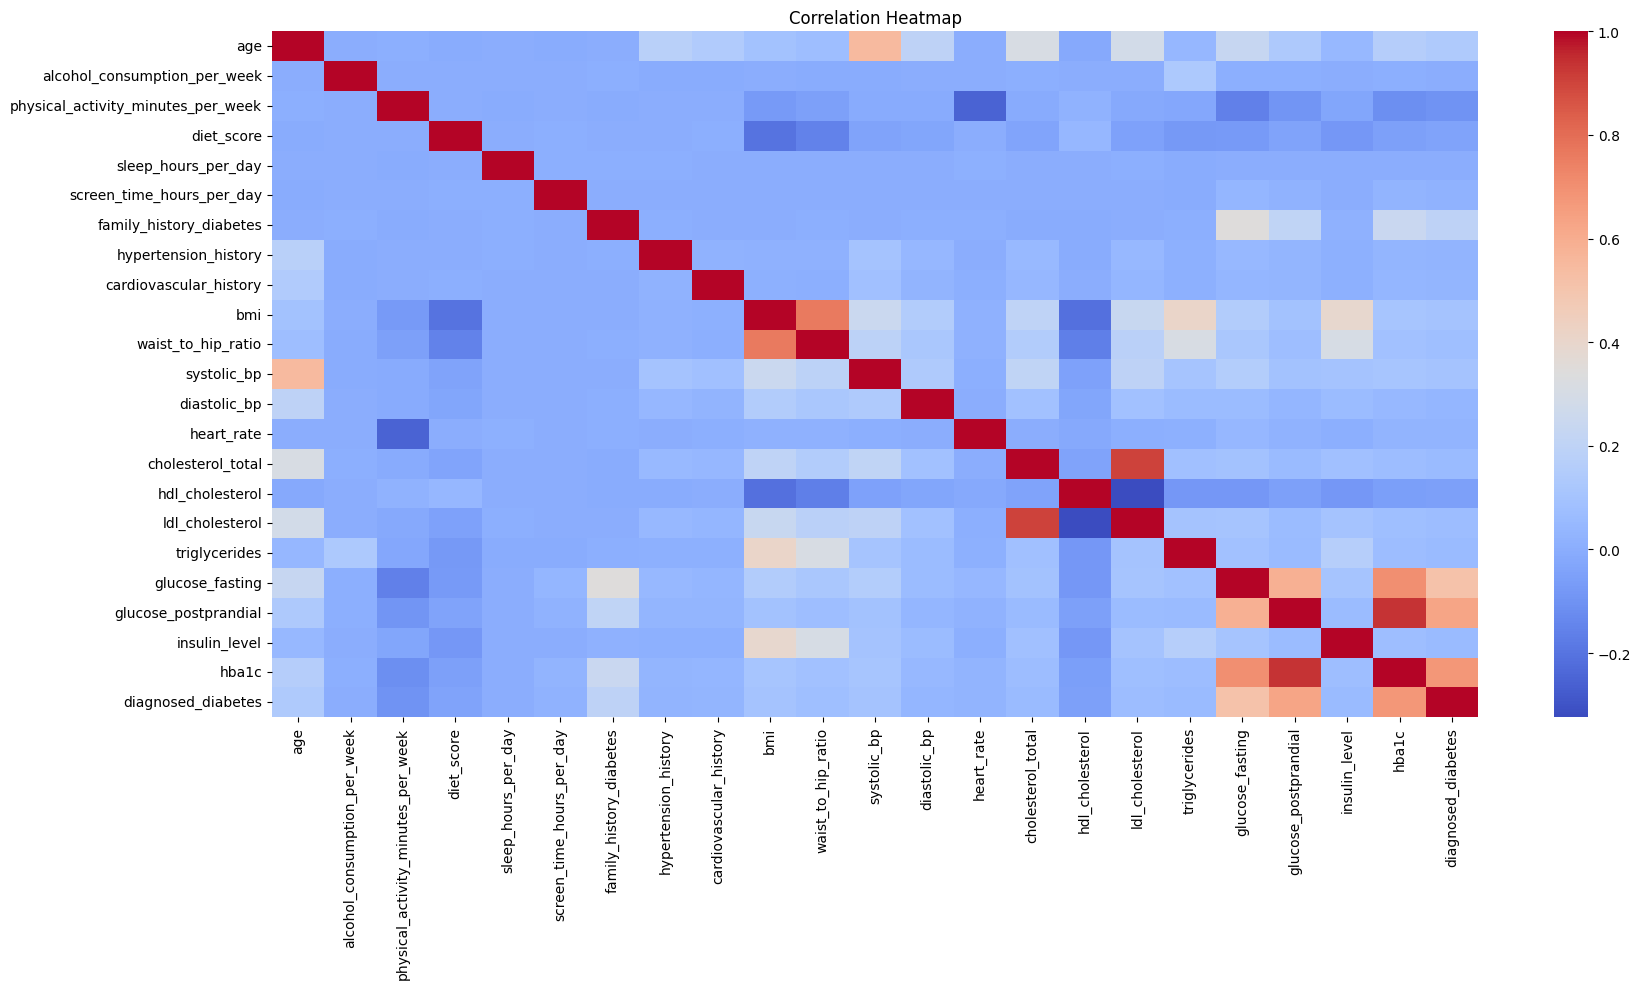

In [51]:
# --- Correlation Heatmap ---
plt.figure(figsize=(18, 10))
corr = df_eda[numerical + ['diagnosed_diabetes']].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

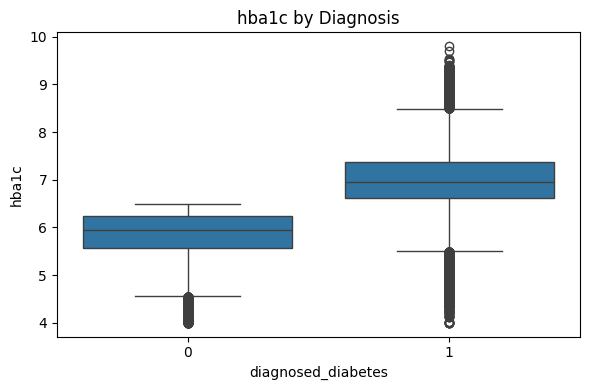

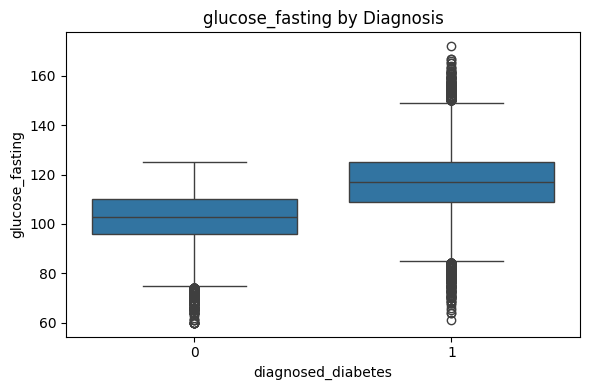

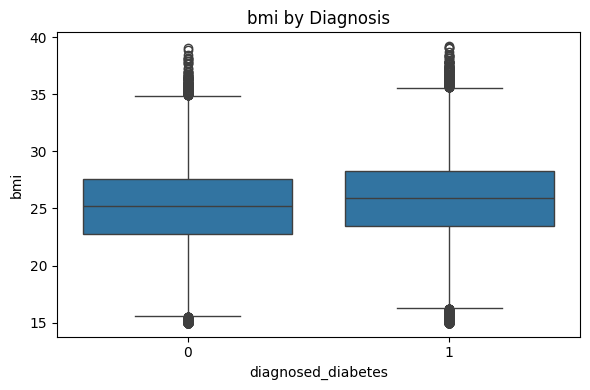

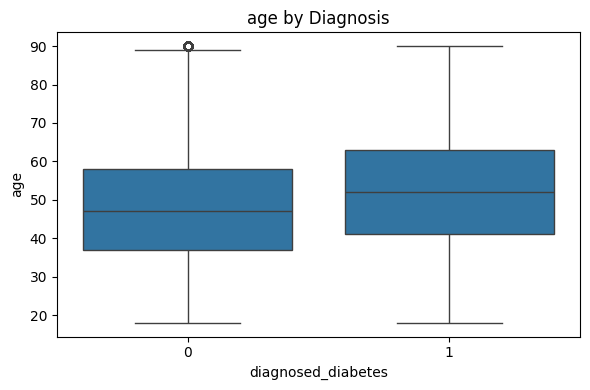

In [52]:
# --- Key Features vs Target ---
important = ['hba1c', 'glucose_fasting', 'bmi', 'age']

for col in important:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_eda, x='diagnosed_diabetes', y=col)
    plt.title(f'{col} by Diagnosis')
    plt.tight_layout()
    plt.show()

## 5. Remove Leaky Features

**`diabetes_risk_score`** and **`diabetes_stage`** are derived from or directly encode the diagnosis label.  
Keeping them causes data leakage — the model learns to read the answer rather than the clinical signals.  
Removing them brings accuracy from ~0.9996 down to a realistic range.

In [53]:
LEAKY_COLS = ['diabetes_risk_score', 'diabetes_stage']

df_clean = df.drop(columns=LEAKY_COLS, errors='ignore')

print('Removed leaky columns:', LEAKY_COLS)
print('Remaining shape:', df_clean.shape)

Removed leaky columns: ['diabetes_risk_score', 'diabetes_stage']
Remaining shape: (100000, 29)


## 6. Feature Engineering

We create clinically meaningful features that XGBoost would otherwise have to discover from scratch:

| Feature | Clinical meaning |
|---|---|
| `homa_ir` | Insulin resistance proxy (gold standard) |
| `glucose_spike` | Post-meal glucose rise — key diabetes signal |
| `ldl_hdl_ratio` | Cardiovascular + metabolic risk |
| `pulse_pressure` | Arterial stiffness |
| `bmi_category` | WHO obesity classification |
| `hba1c_category` | Clinical prediabetes/diabetes thresholds |
| `age_group` | Age-based risk bands |
| `lifestyle_score` | Composite healthy behaviour index |
| `family_obese` | Family history × obesity interaction |
| `metabolic_syndrome` | Classic metabolic syndrome flag |

In [54]:
df_feat = df_clean.copy()

# ── Clinical Ratios ─────────────────────────────────────────────────────────

# HOMA-IR: gold-standard insulin resistance proxy
df_feat['homa_ir'] = (df_feat['glucose_fasting'] * df_feat['insulin_level']) / 405

# Postprandial glucose spike
df_feat['glucose_spike'] = df_feat['glucose_postprandial'] - df_feat['glucose_fasting']

# Lipid ratios
df_feat['ldl_hdl_ratio']  = df_feat['ldl_cholesterol'] / df_feat['hdl_cholesterol']
df_feat['chol_hdl_ratio'] = df_feat['cholesterol_total'] / df_feat['hdl_cholesterol']

# Arterial stiffness
df_feat['pulse_pressure'] = df_feat['systolic_bp'] - df_feat['diastolic_bp']

print('Clinical ratio features created.')

Clinical ratio features created.


In [55]:
# ── Binned Clinical Thresholds ───────────────────────────────────────────────

# WHO BMI classification
df_feat['bmi_category'] = pd.cut(
    df_feat['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['underweight', 'normal', 'overweight', 'obese']
).astype(str)

# ADA HbA1c thresholds — these are the actual diagnostic cutoffs
df_feat['hba1c_category'] = pd.cut(
    df_feat['hba1c'],
    bins=[0, 5.7, 6.5, 100],
    labels=['normal', 'prediabetic', 'diabetic']
).astype(str)

# Age risk bands
df_feat['age_group'] = pd.cut(
    df_feat['age'],
    bins=[0, 35, 50, 65, 120],
    labels=['young', 'middle', 'senior', 'elderly']
).astype(str)

print('Binned threshold features created.')

Binned threshold features created.


In [56]:
# ── Composite Lifestyle Score ────────────────────────────────────────────────
# Normalise each lifestyle column to [0,1] then combine:
# positive contributors (+): activity, diet, sleep
# negative contributors (−): screen time, alcohol

lifestyle_cols = [
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'alcohol_consumption_per_week'
]

scaler = MinMaxScaler()
ls = scaler.fit_transform(df_feat[lifestyle_cols])

df_feat['lifestyle_score'] = (
      ls[:, 0]   # activity  (+)
    + ls[:, 1]   # diet      (+)
    + ls[:, 2]   # sleep     (+)
    - ls[:, 3]   # screen    (−)
    - ls[:, 4]   # alcohol   (−)
)

print('Lifestyle score created.')

Lifestyle score created.


In [57]:
# ── Interaction / Risk Flags ─────────────────────────────────────────────────

# Family history + obesity — multiplicative risk
df_feat['family_obese'] = (
    (df_feat['family_history_diabetes'] == 1) &
    (df_feat['bmi'] >= 30)
).astype(int)

# Metabolic syndrome proxy (3 classic criteria)
df_feat['metabolic_syndrome'] = (
    (df_feat['bmi'] >= 30) &
    (df_feat['systolic_bp'] >= 130) &
    (df_feat['triglycerides'] >= 150)
).astype(int)

print('Interaction flags created.')
print('Final dataset shape:', df_feat.shape)
df_feat.head(3)

Interaction flags created.
Final dataset shape: (100000, 40)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,glucose_spike,ldl_hdl_ratio,chol_hdl_ratio,pulse_pressure,bmi_category,hba1c_category,age_group,lifestyle_score,family_obese,metabolic_syndrome
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,100,3.902439,5.829268,56,obese,diabetic,senior,1.074116,0,0
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,57,0.909091,2.109091,53,normal,normal,middle,0.738601,0,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,77,1.500000,3.227273,42,normal,diabetic,senior,1.142170,0,0


## 7. Feature & Target Split

In [58]:
X = df_feat.drop('diagnosed_diabetes', axis=1)
y = df_feat['diagnosed_diabetes']

# Identify column types after feature engineering
new_cat_cols = ['bmi_category', 'hba1c_category', 'age_group']
categorical_final = X.select_dtypes(include='object').columns.tolist()
numerical_final   = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical features:', len(categorical_final))
print('Numerical features  :', len(numerical_final))
print('Total features      :', X.shape[1])

Categorical features: 9
Numerical features  : 30
Total features      : 39


## 8. Preprocessing Pipeline

In [59]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numerical_final),
    ('cat', categorical_transformer, categorical_final)
])

print('Preprocessing pipeline built.')

Preprocessing pipeline built.


## 9. Cross-Validation Evaluation

**Stratified 5-Fold CV** trains 5 separate models, each on a different 80% slice of the data and evaluates on the remaining 20%.  
This gives a reliable mean ± std AUC and ensures every sample is in the test set exactly once — unlike a single train/test split.

In [60]:
xgb_cv = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

pipeline_cv = Pipeline([
    ('preprocessing', preprocessor),
    ('model', xgb_cv)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_cv,
    X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print('ROC AUC per fold:', cv_scores.round(4))
print(f'Mean AUC : {cv_scores.mean():.4f}')
print(f'Std  AUC : {cv_scores.std():.4f}')

ROC AUC per fold: [0.9447 0.9463 0.9447 0.9431 0.9447]
Mean AUC : 0.9447
Std  AUC : 0.0010


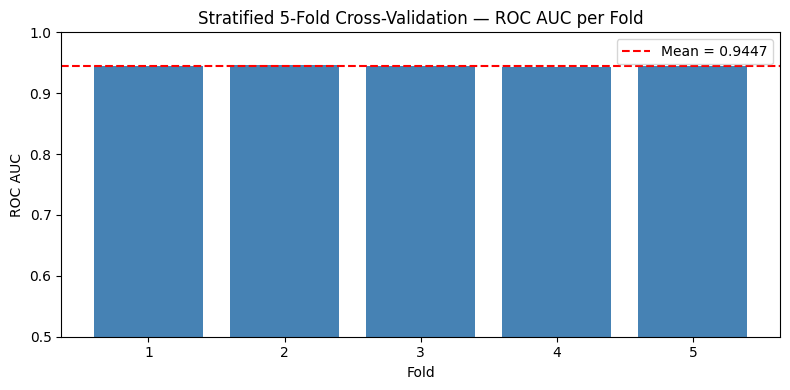

In [61]:
# Visualise fold scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC AUC')
plt.title('Stratified 5-Fold Cross-Validation — ROC AUC per Fold')
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Final Model — Train with Early Stopping

We now train on 80% of the data with an explicit validation set.  
**Early stopping** monitors validation log-loss and halts training if it does not improve for 30 consecutive rounds — this finds the optimal number of trees automatically and prevents overfitting.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (80000, 39)
Test size : (20000, 39)


In [63]:
# Fit the preprocessor on train, transform both splits
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print('Preprocessed train shape:', X_train_proc.shape)
print('Preprocessed test shape :', X_test_proc.shape)

Preprocessed train shape: (80000, 65)
Preprocessed test shape : (20000, 65)


In [64]:
xgb_final = XGBClassifier(
    n_estimators=1000,           # high ceiling — early stopping decides when to stop
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30,   # stop if no improvement for 30 rounds
    n_jobs=-1
)

xgb_final.fit(
    X_train_proc, y_train,
    eval_set=[(X_test_proc, y_test)],
    verbose=50
)

print(f'\nOptimal number of trees: {xgb_final.best_iteration}')

[0]	validation_0-logloss:0.63863
[50]	validation_0-logloss:0.23218
[100]	validation_0-logloss:0.21520
[150]	validation_0-logloss:0.21441
[194]	validation_0-logloss:0.21458

Optimal number of trees: 164


## 11. Evaluation

In [65]:
pred  = xgb_final.predict(X_test_proc)
probs = xgb_final.predict_proba(X_test_proc)[:, 1]

print('Accuracy:', accuracy_score(y_test, pred))
print()
print(classification_report(y_test, pred))

Accuracy: 0.9199

              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



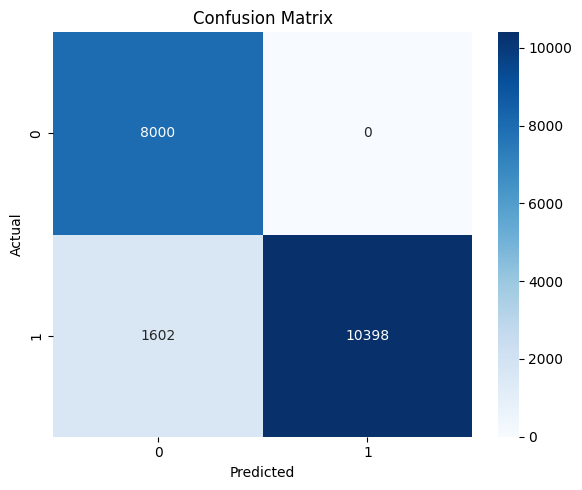

In [66]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

ROC AUC: 0.9435465416666666


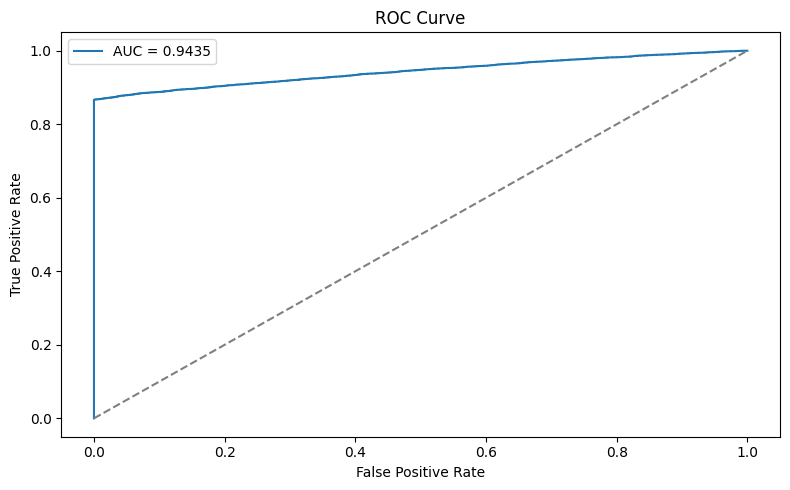

In [67]:
# ROC Curve
auc = roc_auc_score(y_test, probs)
print('ROC AUC:', auc)

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

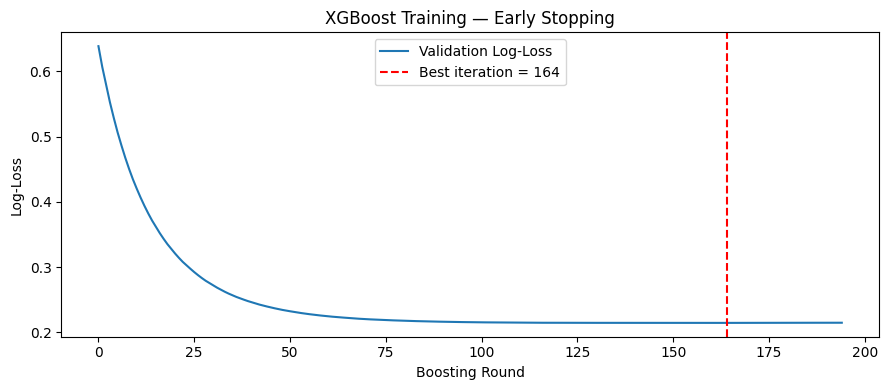

In [68]:
# Early Stopping Loss Curve
results = xgb_final.evals_result()
epochs  = len(results['validation_0']['logloss'])

plt.figure(figsize=(9, 4))
plt.plot(range(epochs), results['validation_0']['logloss'], label='Validation Log-Loss')
plt.axvline(xgb_final.best_iteration, color='red', linestyle='--',
            label=f'Best iteration = {xgb_final.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Log-Loss')
plt.title('XGBoost Training — Early Stopping')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Feature Importance

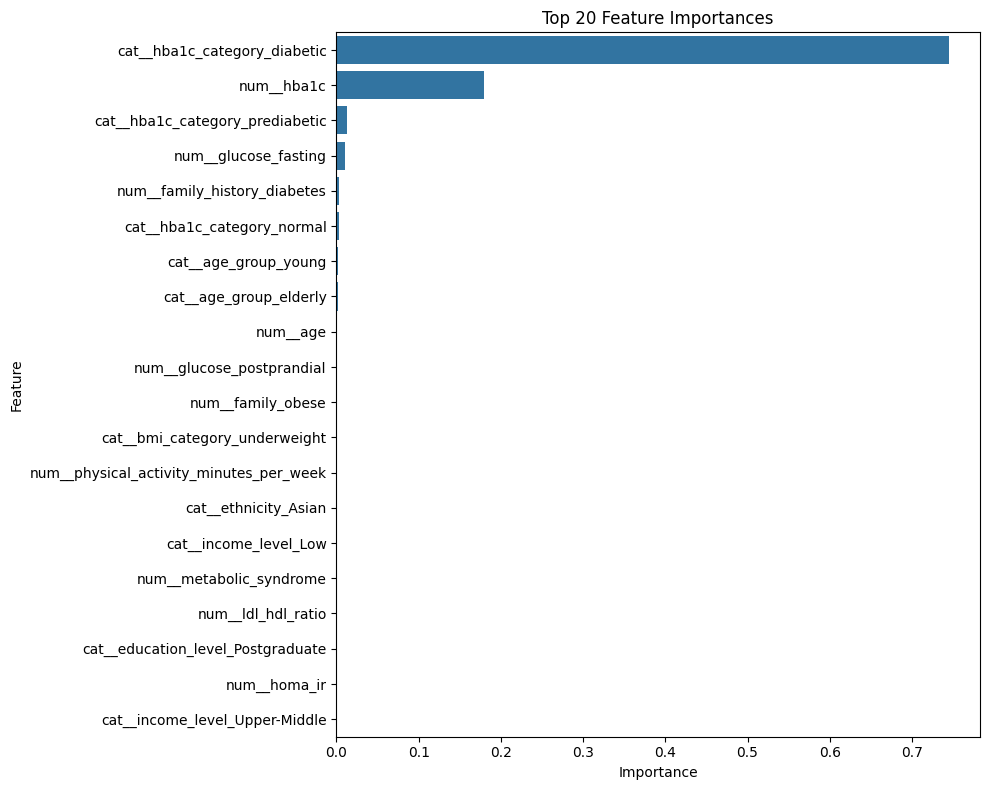

In [69]:
feature_names = preprocessor.get_feature_names_out()
importance    = xgb_final.feature_importances_

feature_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_df.head(20), x='Importance', y='Feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## 13. Save Final Model

We wrap the fitted preprocessor + final XGBoost model into a single object for easy inference.

In [70]:
# Bundle preprocessor + model for clean inference
final_bundle = {
    'preprocessor': preprocessor,
    'model':        xgb_final,
    'feature_cols': X.columns.tolist()
}

os.makedirs('Models', exist_ok=True)
joblib.dump(final_bundle, 'Models/diabetes_xgboost_pipeline.pkl')

print('Model saved to Models/diabetes_xgboost_pipeline.pkl')

Model saved to Models/diabetes_xgboost_pipeline.pkl


In [72]:
# ── Inference example ────────────────────────────────────────────────────────
bundle = joblib.load('Models/diabetes_xgboost_pipeline.pkl')
X_new = X_test.head(1)  # or construct a new DataFrame with the same feature columns
X_new_proc = bundle['preprocessor'].transform(X_new)

preds = bundle['model'].predict(X_new_proc)
probs = bundle['model'].predict_proba(X_new_proc)[:, 1]
preds      = bundle['model'].predict(X_new_proc)
probs      = bundle['model'].predict_proba(X_new_proc)[:, 1]

In [73]:
print('Predicted class:', preds[0])
print('Predicted probability of diabetes:', probs[0])

Predicted class: 0
Predicted probability of diabetes: 0.20683727
